In [1]:
#Geographic Information Systems

In [2]:
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot, plot
init_notebook_mode(connected=True)

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv('2014_World_Power_Consumption')

In [5]:
df.head()

,Country,Power Consumption KWH,Text
0,China,5.523000e+12,"China 5,523,000,000,000"
1,United States,3.832000e+12,"United 3,832,000,000,000"
2,European,2.771000e+12,"European 2,771,000,000,000"
3,Russia,1.065000e+12,"Russia 1,065,000,000,000"
4,Japan,9.210000e+11,"Japan 921,000,000,000"


In [6]:
data=dict(
    type="choropleth",
    colorscale='Viridis',
    reversescale=True,
    locations=df["Country"],
    locationmode="country names",
    z=df["Power Consumption KWH"],
    text=df["Country"],
    colorbar={'title':"World Power Consunmption"}
)
layout=dict(title="World Power Consunmption",
            width=1400,      # <-- BIGGER WIDTH
            height=900, 
            geo=dict(showframe=False,projection={'type':'mercator'})
            )

C:\Users\Kullanıcı\AppData\Local\Temp\ipykernel_52896\4065799151.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



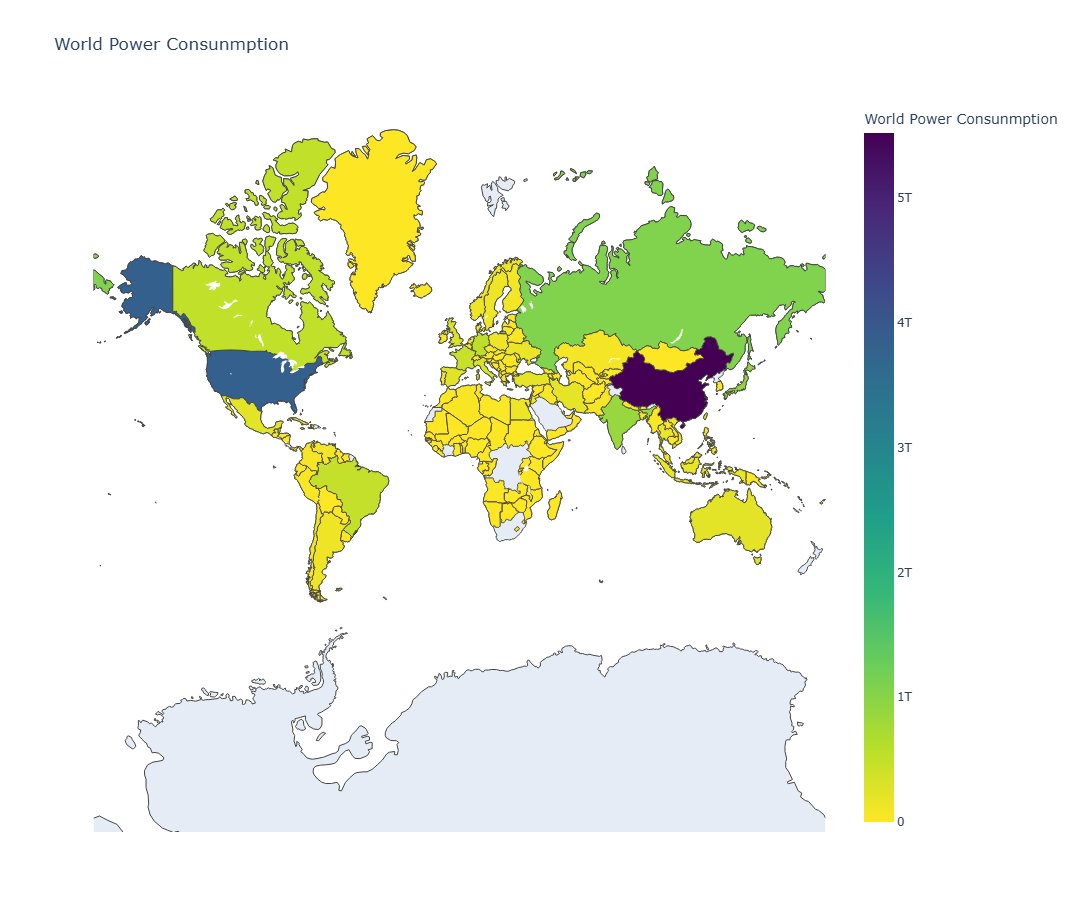

In [7]:
choromap=go.Figure(data=data,layout=layout)
iplot(choromap,validate=False)

In [8]:
from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/fips-unemp-16.csv",
                   dtype={"fips": str})

C:\Users\Kullanıcı\AppData\Local\Temp\ipykernel_52896\2481563717.py:6: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



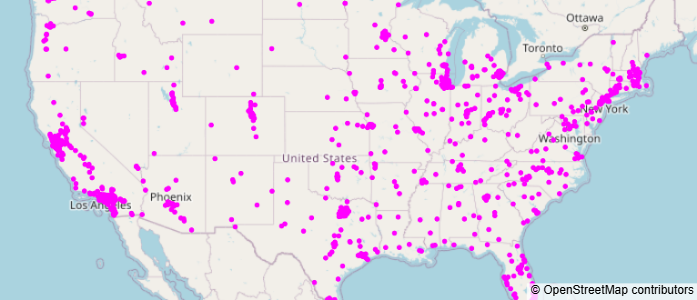

In [9]:
import pandas as pd
us_cities = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv")

import plotly.express as px

fig = px.scatter_mapbox(us_cities, lat="lat", lon="lon", hover_name="City", hover_data=["State", "Population"],
                        color_discrete_sequence=["fuchsia"], zoom=3, height=300)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

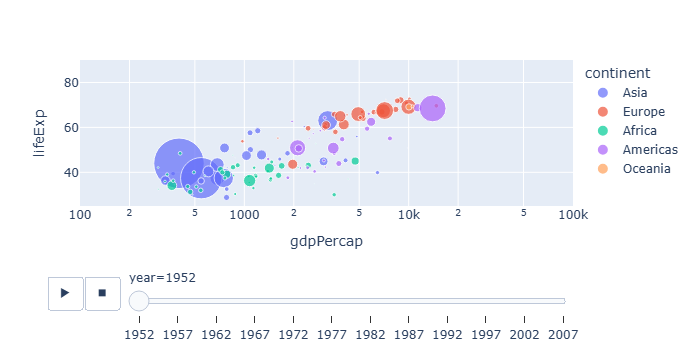

In [10]:
import plotly.express as px
df = px.data.gapminder()
px.scatter(df, x="gdpPercap", y="lifeExp", animation_frame="year", animation_group="country",
           size="pop", color="continent", hover_name="country",
           log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])


C:\Users\Kullanıcı\AppData\Local\Temp\ipykernel_52896\3771995166.py:6: DeprecationWarning:

*choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



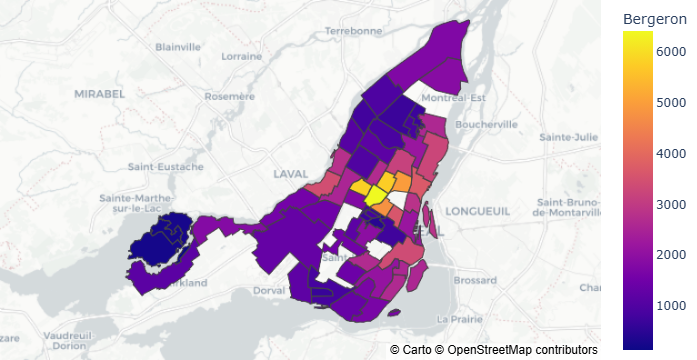

In [11]:
import plotly.express as px

df = px.data.election()
geojson = px.data.election_geojson()

fig = px.choropleth_mapbox(df, geojson=geojson, color="Bergeron",
                           locations="district", featureidkey="properties.district",
                           center={"lat": 45.5517, "lon": -73.7073},
                           mapbox_style="carto-positron", zoom=9)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()


In [12]:
pip install leafmap

  Using cached eval_type_backport-0.3.1-py3-none-any.whl.metadata (2.4 kB)
   ---------------------------------------- 0.0/667.8 kB ? eta -:--:--
   ------------------------------- -------- 524.3/667.8 kB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 667.8/667.8 kB 2.7 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 4.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/12.3 MB 4.4 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.3 MB 4.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.3 MB 4.9 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.3 MB 5.1 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.3 MB 5.2 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.3 MB 5.2 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.3 MB 5.2 MB/s eta 0:00:01
   --------

In [13]:
import leafmap.foliumap as leafmap

In [14]:
import leafmap.foliumap as leafmap
m = leafmap.Map()
m.add_basemap("USGS 3DEP Elevation")
colors = ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"]
vmin = 0
vmax = 4000
m.add_colorbar(colors=colors, vmin=vmin, vmax=vmax)
m